# Stage 3: Data Preprocessing & Cleaning

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('./data/raw/water_potability.csv')
print(f'Loaded: {df.shape} | Missing values: {df.isnull().sum().sum()}')

Loaded: (3276, 10) | Missing values: 1434


## 3.1 Strategy: Median Imputation Per Class

We impute missing values using the **median of each class** (Potable vs Non-Potable) separately. This is better than global median imputation because the distributions of features differ by class.

In [2]:
# Record missing before
missing_before = df.isnull().sum()

# Class-wise median imputation
features_with_missing = ['ph', 'Sulfate', 'Trihalomethanes']

for feature in features_with_missing:
    class_medians = df.groupby('Potability')[feature].median()
    print(f'\n{feature} median by class:')
    print(f'  Non-Potable (0): {class_medians[0]:.4f}')
    print(f'  Potable (1):     {class_medians[1]:.4f}')
    
    for cls in [0, 1]:
        mask = (df['Potability'] == cls) & (df[feature].isnull())
        df.loc[mask, feature] = class_medians[cls]

print(f'\n✓ Missing values after imputation: {df.isnull().sum().sum()}')


ph median by class:
  Non-Potable (0): 7.0355
  Potable (1):     7.0368

Sulfate median by class:
  Non-Potable (0): 333.3894
  Potable (1):     331.8382

Trihalomethanes median by class:
  Non-Potable (0): 66.5422
  Potable (1):     66.6782

✓ Missing values after imputation: 0


## 3.2 Outlier Detection & Treatment (IQR Method)

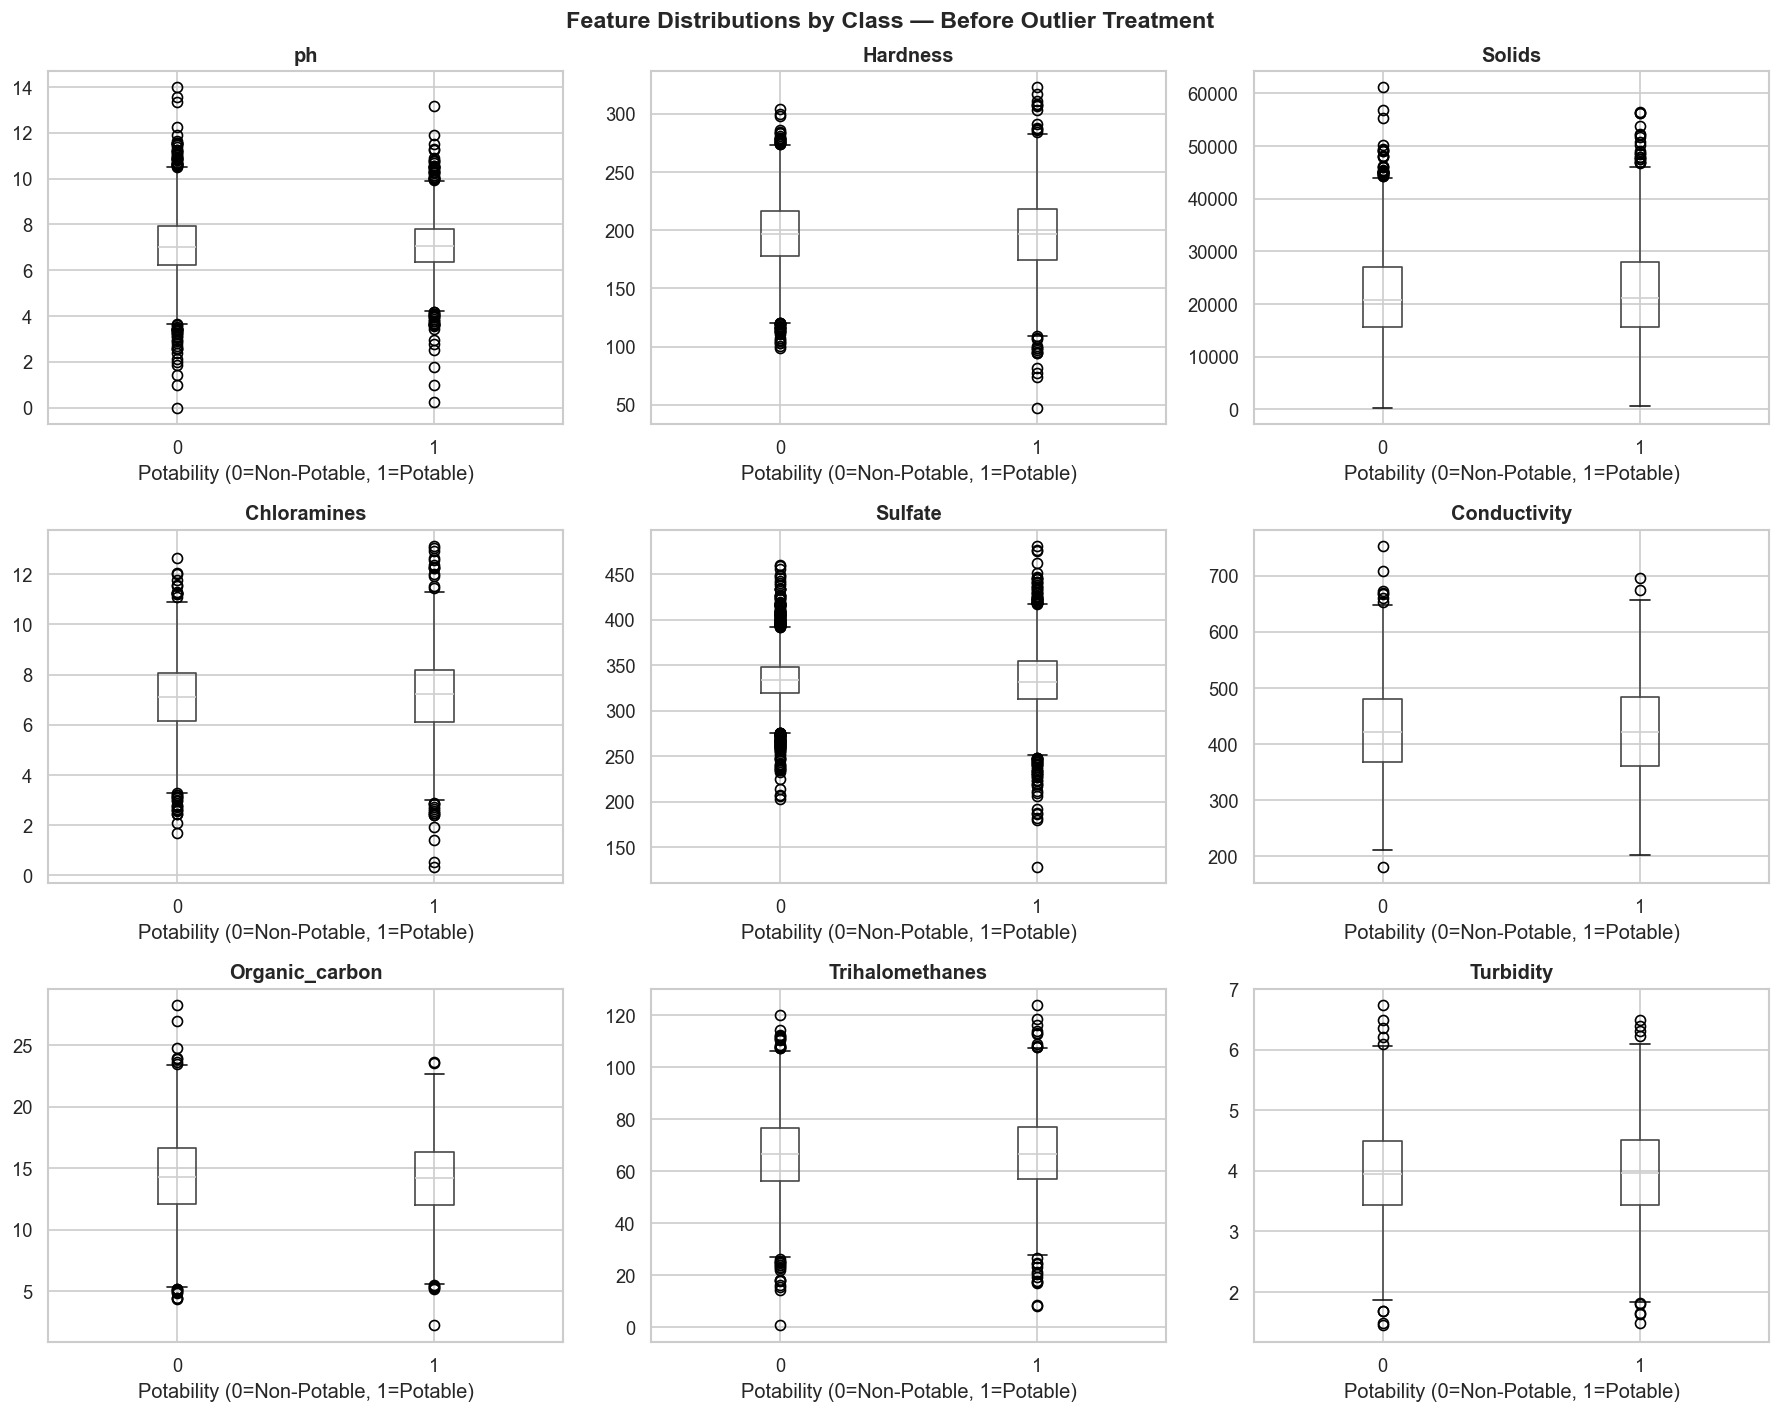

In [3]:
feature_cols = [c for c in df.columns if c != 'Potability']

# Before outlier treatment — boxplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    df.boxplot(column=col, by='Potability', ax=axes[i])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Potability (0=Non-Potable, 1=Potable)')

plt.suptitle('Feature Distributions by Class — Before Outlier Treatment', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/boxplots_before.png', bbox_inches='tight', dpi=150)
plt.show()

In [4]:
# IQR capping (Winsorization) — cap outliers at 1.5*IQR bounds
# We cap rather than drop to preserve data (only 3276 rows)
outlier_report = []

for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({'Feature': col, 'Lower Bound': round(lower, 3),
                            'Upper Bound': round(upper, 3), 'Outliers Found': n_outliers})
    
    # Cap the outliers
    df[col] = df[col].clip(lower=lower, upper=upper)

outlier_df = pd.DataFrame(outlier_report)
print('OUTLIER TREATMENT REPORT')
print(outlier_df.to_string(index=False))

OUTLIER TREATMENT REPORT
        Feature  Lower Bound  Upper Bound  Outliers Found
             ph        3.889       10.259             142
       Hardness      117.125      276.393              83
         Solids    -1832.417    44831.870              47
    Chloramines        3.146       11.096              61
        Sulfate      267.158      400.322             264
   Conductivity      191.648      655.879              11
 Organic_carbon        5.328       23.295              25
Trihalomethanes       26.619      106.695              54
      Turbidity        1.849        6.091              19


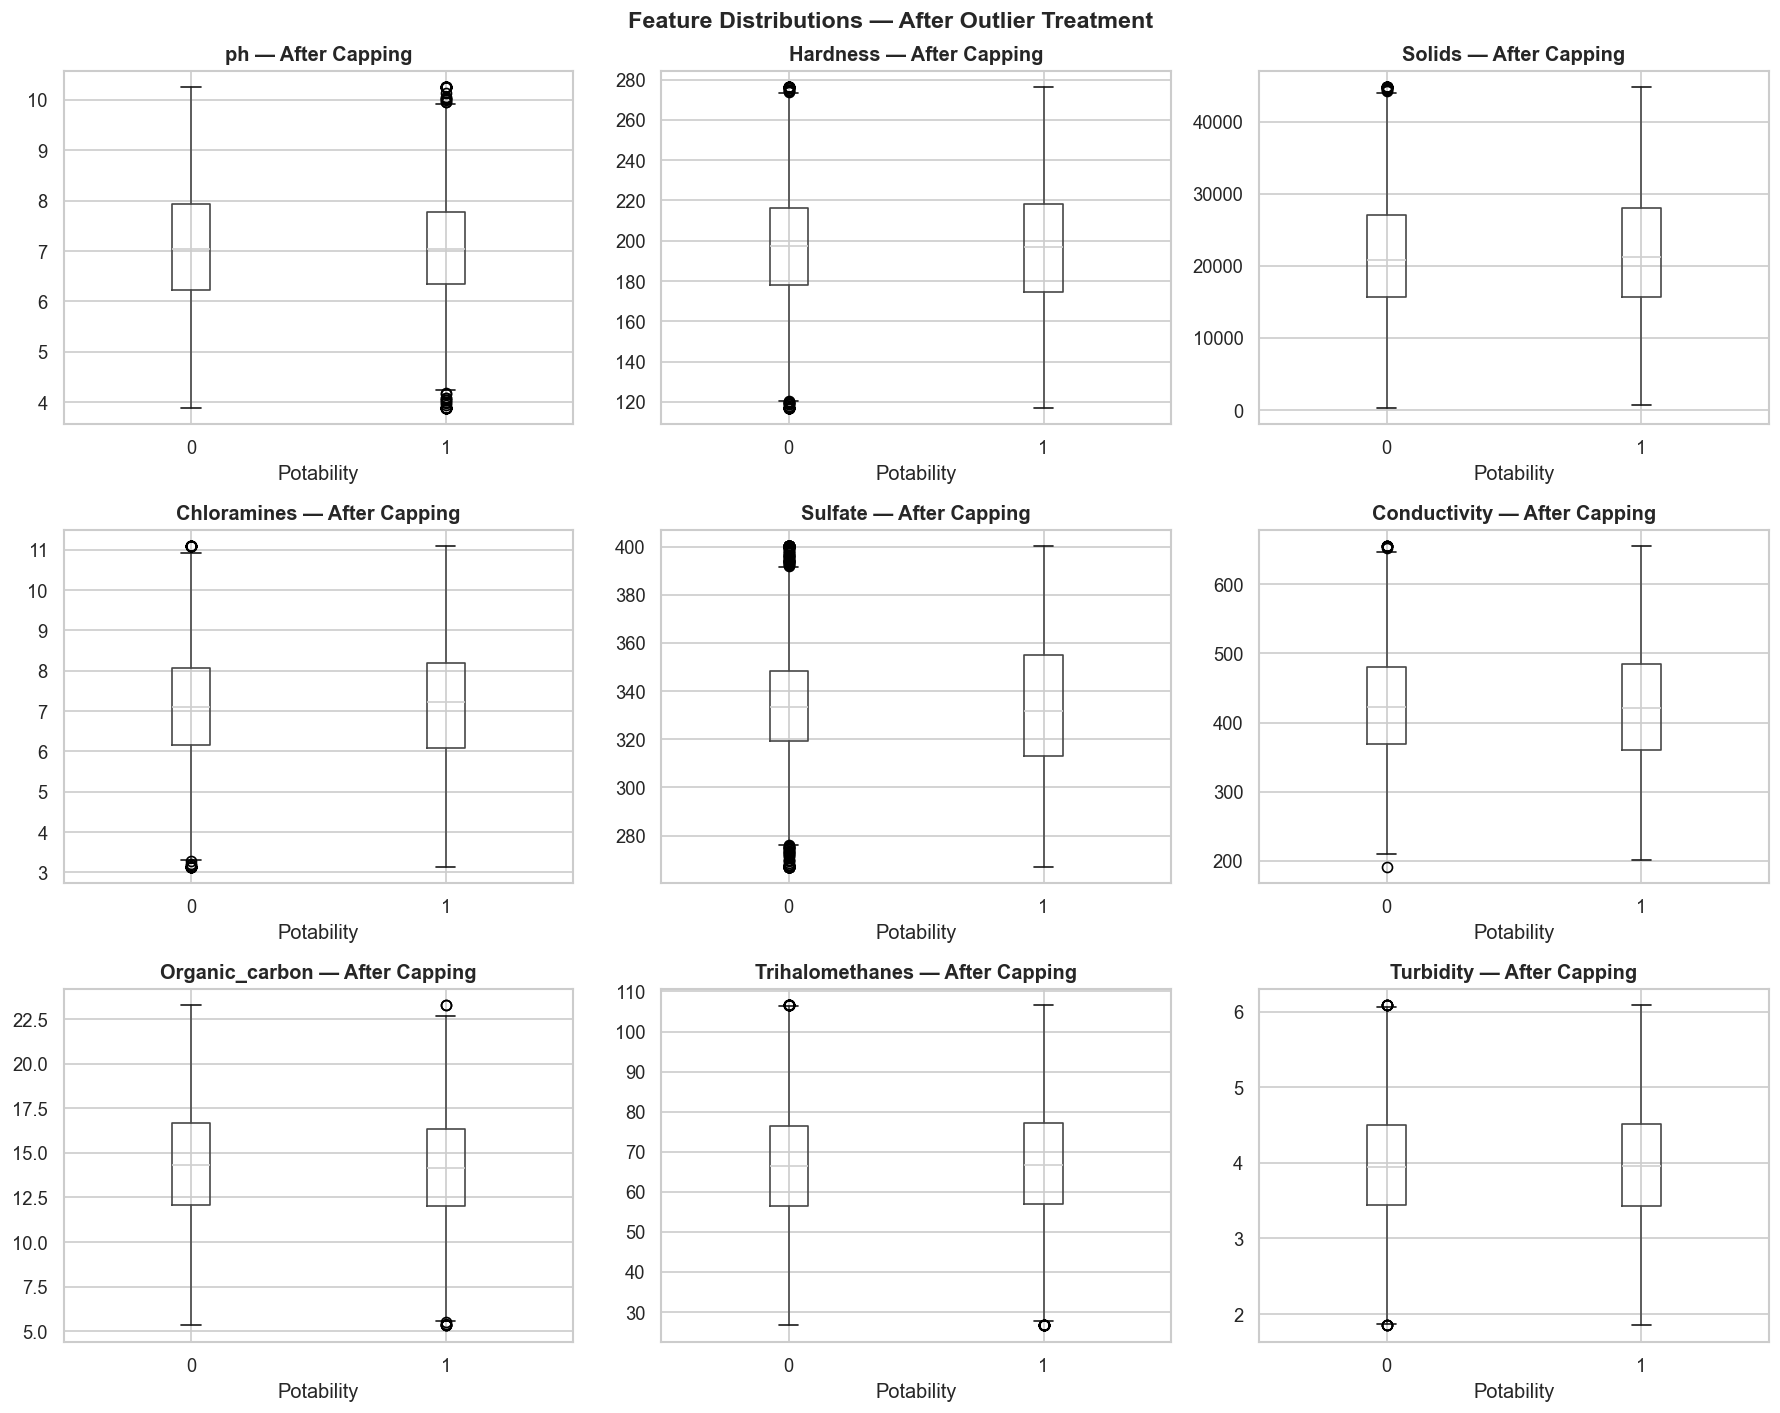

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    df.boxplot(column=col, by='Potability', ax=axes[i])
    axes[i].set_title(f'{col} — After Capping', fontweight='bold')
plt.suptitle('Feature Distributions — After Outlier Treatment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/boxplots_after.png', bbox_inches='tight', dpi=150)
plt.show()

## 3.3 Duplicate Check

In [6]:
dupes = df.duplicated().sum()
print(f'Duplicate rows found: {dupes}')
if dupes > 0:
    df = df.drop_duplicates()
    print(f'Removed duplicates. New shape: {df.shape}')
else:
    print('No duplicates — dataset is clean ✓')

Duplicate rows found: 0
No duplicates — dataset is clean ✓


## 3.4 Data Type Validation

In [7]:
# Ensure all features are float, target is int
for col in feature_cols:
    df[col] = df[col].astype(float)
df['Potability'] = df['Potability'].astype(int)

print('Data types after validation:')
print(df.dtypes)
print(f'\nFinal dataset shape: {df.shape}')
print(f'Missing values remaining: {df.isnull().sum().sum()}')

Data types after validation:
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

Final dataset shape: (3276, 10)
Missing values remaining: 0


## 3.5 Save Cleaned Dataset

In [8]:
df.to_csv('./data/processed/water_potability_cleaned.csv', index=False)
print('✓ Cleaned dataset saved: data/processed/water_potability_cleaned.csv')
print(f'  Rows: {len(df)} | Columns: {df.shape[1]} | Missing: {df.isnull().sum().sum()}')

✓ Cleaned dataset saved: data/processed/water_potability_cleaned.csv
  Rows: 3276 | Columns: 10 | Missing: 0
